<a href="https://colab.research.google.com/github/Nourin-Nusrat/CSE4261_DNN/blob/main/Assignment9/DNN_Assignment_9_1_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Imports

In [1]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
import numpy as np
import umap


# CIFAR-10 Dataset

In [2]:
transform = transforms.Compose([
    transforms.ToTensor(),
])
train_dataset = torchvision.datasets.CIFAR10(root='./data', train=True, transform=transform, download=True)
train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)
classes = train_dataset.classes

100%|██████████| 170M/170M [00:03<00:00, 48.6MB/s]


## Autoencoder

In [3]:

class Autoencoder(nn.Module):
    def __init__(self):
        super(Autoencoder, self).__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 16, 3, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(16, 32, 3, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 64, 3, stride=2, padding=1),
            nn.ReLU()
        )
        self.fc = nn.Linear(64 * 4 * 4, 2)

        self.decoder = nn.Sequential(
            nn.Linear(2, 64 * 4 * 4),
            nn.Unflatten(1, (64, 4, 4)),
            nn.ConvTranspose2d(64, 32, 3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(32, 16, 3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(16, 3, 3, stride=2, padding=1, output_padding=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        encoded = self.encoder(x)
        bottleneck = self.fc(encoded.view(x.size(0), -1))
        decoded = self.decoder(bottleneck)
        return bottleneck, decoded


# Train Autoencoder

In [4]:

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
autoencoder = Autoencoder().to(device)
optimizer = torch.optim.Adam(autoencoder.parameters(), lr=1e-3)
criterion = nn.MSELoss()
print("Training autoencoder...")
for epoch in range(20):
    for images, _ in train_loader:
        images = images.to(device)
        bottleneck, outputs = autoencoder(images)
        loss = criterion(outputs, images)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    print(f"Epoch {epoch+1}: Loss = {loss.item():.4f}")

Training autoencoder...
Epoch 1: Loss = 0.0344
Epoch 2: Loss = 0.0366
Epoch 3: Loss = 0.0394
Epoch 4: Loss = 0.0374
Epoch 5: Loss = 0.0372
Epoch 6: Loss = 0.0390
Epoch 7: Loss = 0.0387
Epoch 8: Loss = 0.0344
Epoch 9: Loss = 0.0367
Epoch 10: Loss = 0.0368
Epoch 11: Loss = 0.0370
Epoch 12: Loss = 0.0353
Epoch 13: Loss = 0.0378
Epoch 14: Loss = 0.0395
Epoch 15: Loss = 0.0372
Epoch 16: Loss = 0.0347
Epoch 17: Loss = 0.0388
Epoch 18: Loss = 0.0386
Epoch 19: Loss = 0.0350
Epoch 20: Loss = 0.0342



# Autoencoder Feature Extract

In [5]:
def extract_autoencoder_features(model, loader, device):
    model.eval()
    features, labels = [], []
    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            z, _ = model(x)
            features.append(z.cpu().numpy())
            labels.append(y.numpy())
    return np.concatenate(features), np.concatenate(labels)

ae_features, ae_labels = extract_autoencoder_features(autoencoder, train_loader, device)

# Plotting Function

In [6]:
def plot_2d_features(features, labels, title):
    plt.figure(figsize=(6, 5))
    scatter = plt.scatter(features[:, 0], features[:, 1], c=labels, cmap='tab10', s=10, alpha=0.7)
    plt.legend(handles=scatter.legend_elements()[0], labels=classes, bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')
    plt.title(title)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

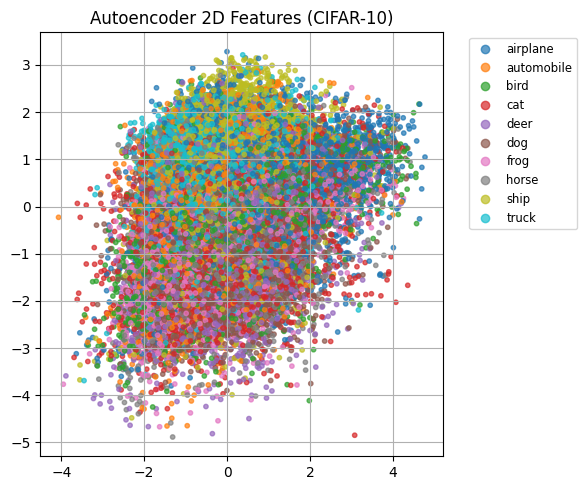

In [7]:
plt.figure(figsize=(6, 5))
scatter = plt.scatter(ae_features[:, 0], ae_features[:, 1], c=ae_labels, cmap='tab10', s=10, alpha=0.7)
plt.legend(handles=scatter.legend_elements()[0], labels=classes, bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')
plt.title("Autoencoder 2D Features (CIFAR-10)")
plt.grid(True)
plt.tight_layout()
plt.show()

#ResNet50 Feature Extractor

In [8]:

from torchvision.models import resnet50
class ResNetFeatureExtractor(nn.Module):
    def __init__(self):
        super().__init__()
        model = resnet50(pretrained=True)
        self.backbone = nn.Sequential(*list(model.children())[:-1])  # remove FC

    def forward(self, x):
        x = self.backbone(x)
        return x.view(x.size(0), -1)

resnet_model = ResNetFeatureExtractor().to(device).eval()

def extract_resnet_features(model, loader, device):
    features, labels = [], []
    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            feats = model(x)
            features.append(feats.cpu().numpy())
            labels.append(y.numpy())
    return np.concatenate(features), np.concatenate(labels)

resnet_feats, resnet_labels = extract_resnet_features(resnet_model, train_loader, device)

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth
100%|██████████| 97.8M/97.8M [00:00<00:00, 151MB/s]


# Dimensionality Reduction

In [9]:
pca_feats = PCA(n_components=2).fit_transform(resnet_feats)
tsne_feats = TSNE(n_components=2, perplexity=30, init='pca').fit_transform(resnet_feats[:2000])
tsne_labels = resnet_labels[:2000]

umap_model = umap.UMAP(n_components=2, random_state=42)
umap_feats = umap_model.fit_transform(resnet_feats[:2000])
umap_labels = resnet_labels[:2000]

/usr/local/lib/python3.11/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


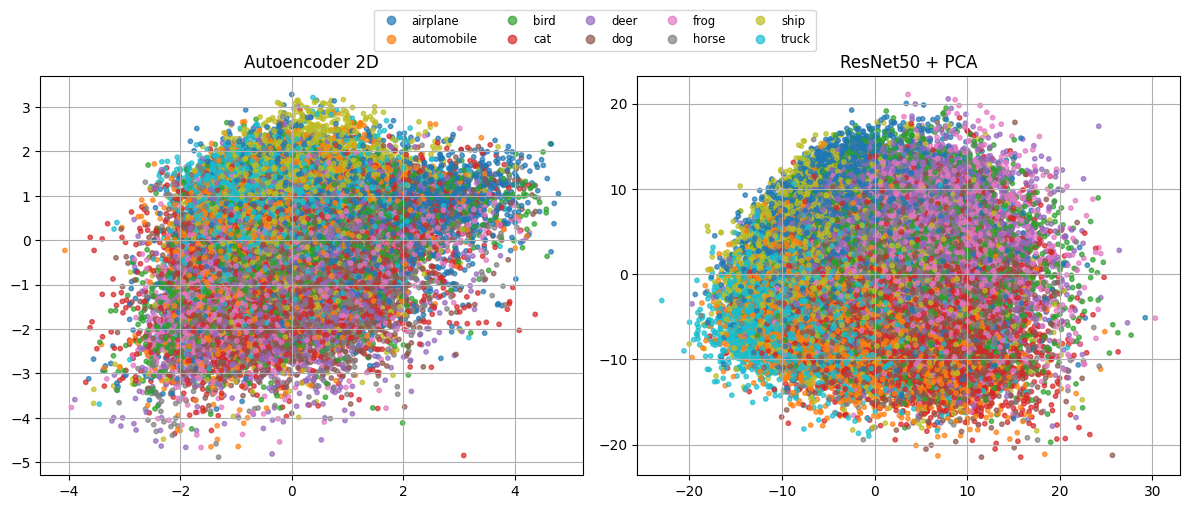

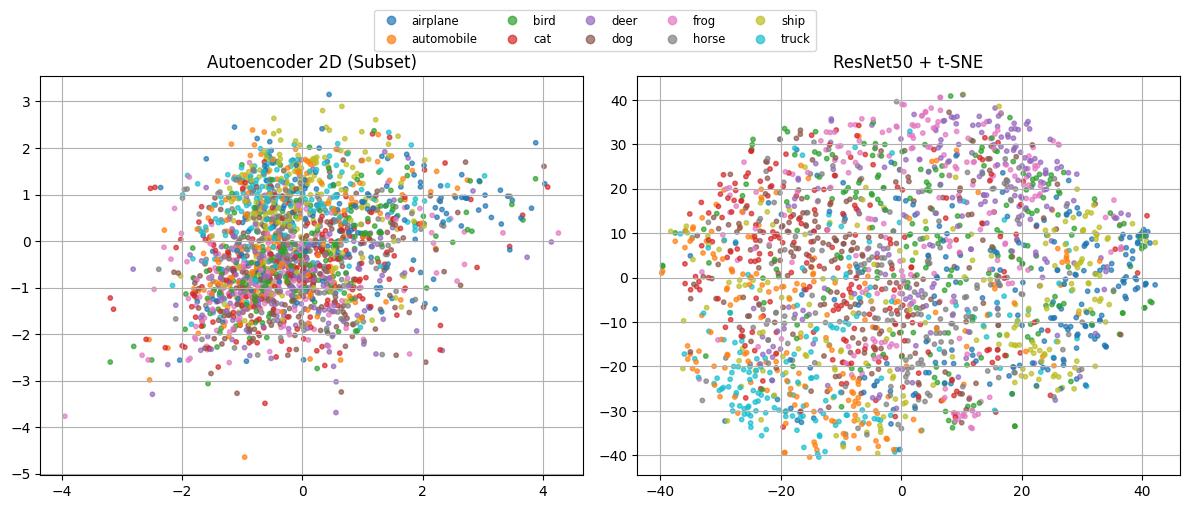

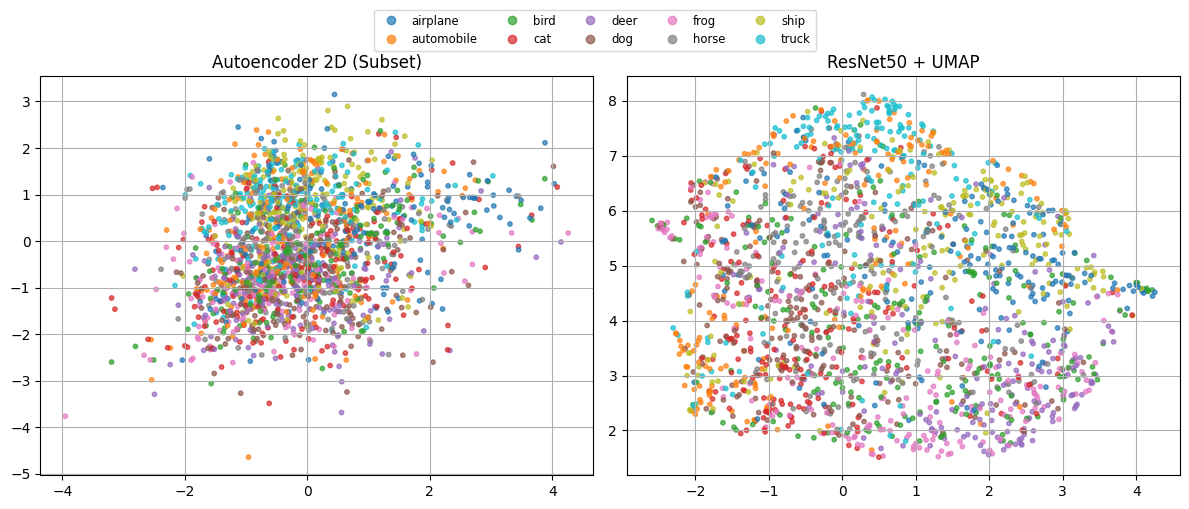

In [11]:
def plot_comparison(feat1, labels1, feat2, labels2, title1, title2):
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    scatter1 = axes[0].scatter(feat1[:, 0], feat1[:, 1], c=labels1, cmap='tab10', s=10, alpha=0.7)
    scatter2 = axes[1].scatter(feat2[:, 0], feat2[:, 1], c=labels2, cmap='tab10', s=10, alpha=0.7)

    axes[0].set_title(title1)
    axes[1].set_title(title2)
    for ax in axes:
        ax.grid(True)
    fig.legend(handles=scatter1.legend_elements()[0], labels=classes,
               bbox_to_anchor=(0.5, 1.02), loc='upper center',
               ncol=5, fontsize='small')

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()


plot_comparison(ae_features, ae_labels, pca_feats, resnet_labels, "Autoencoder 2D", "ResNet50 + PCA")
plot_comparison(ae_features[:2000], ae_labels[:2000], tsne_feats, tsne_labels, "Autoencoder 2D (Subset)", "ResNet50 + t-SNE")
plot_comparison(ae_features[:2000], ae_labels[:2000], umap_feats, umap_labels,
                "Autoencoder 2D (Subset)", "ResNet50 + UMAP")